# Предсказание возрастной группы 

**Описание исследования**  
  
в условиях высокой конкуренции на рынке цифровых сервисов и онлайн-рекламы корректное определение характеристик аудитории является ключевым фактором эффективности рекламных кампаний. одним из наиболее значимых параметров таргетинга является возраст пользователя, поскольку разные возрастные группы демонстрируют принципиально отличающиеся интересы, модели поведения и реакцию на рекламные сообщения.  
  
в рамках проекта рассматривается задача многоклассовой классификации — автоматическое определение возрастной категории пользователя на основе данных о его поведении в цифровой среде. источником информации служат логи посещений сайтов, характеристики интернет-активности, взаимодействия с рекламой и используемых устройств.   
  
основная идея исследования заключается в построении модели машинного обучения, способной по агрегированным поведенческим признакам прогнозировать возрастную категорию пользователя.  
  
**Цель исследования**  
  
целью исследования является построение и оценка модели машинного обучения, способной классифицировать пользователей по возрастным группам на основе поведенческих и контекстных признаков, а также анализ качества и устойчивости полученных предсказаний
  
**Задачи исследования**
  
1.	Загрузка и первичная обработка данных  
    • анализ структуры и содержания исходных таблиц  
    • объединение данных из разных источников в единое признаковое пространство  
    • удаление технических и неинформативных признаков  
2.	Проведение исследовательского анализа данных (EDA)  
    • анализ распределений числовых признаков и выявление выбросов  
    • анализ категориальных признаков и их кардинальности     
    • исследование корреляций между признаками и выявление мультиколлинеарности  
3.	Формирование и подготовка признаков  
    • разработка единой функции формирования итогового датафрейма  
    • отбор признаков с учётом информативности и мультиколлинеарности  
4.	Подготовка данных для обучения моделей    
    • разделение пользователей на обучающую и тестовую выборки
    • сохранение баланса классов при разбиении  
    • разработка пайплайна для обработки данных  
5.	Построение и обучение моделей  
    • построение базовой модели (DummyClassifier) для оценки качества бейзлайна  
    • обучение моделей логистической регрессии и линейного SVC  
    • подбор гиперпараметров с использованием кросс-валидации  
    • оценка качества моделей по метрике F1-macro  
6.	Анализ результатов и интерпретация  
    • сравнение качества моделей на кросс-валидации и тестовой выборке    
7.	Подготовка модели к внедрению  
    • сохранение модели и всех необходимых артефактов предобработки  
    • проверка корректности загрузки и воспроизводимости результатов   

## Подготовка среды и библиотек

### Подготовка библиотек

In [1]:
pip -q install phik 

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip uninstall -y numpy scipy pandas matplotlib seaborn pyarrow numba llvmlite phik statsmodels scikit-learn category-encoders joblib

Found existing installation: numpy 1.21.1
Uninstalling numpy-1.21.1:
  Successfully uninstalled numpy-1.21.1
Found existing installation: scipy 1.9.1
Uninstalling scipy-1.9.1:
  Successfully uninstalled scipy-1.9.1
Found existing installation: pandas 1.2.4
Uninstalling pandas-1.2.4:
  Successfully uninstalled pandas-1.2.4
Found existing installation: matplotlib 3.3.4
Uninstalling matplotlib-3.3.4:
  Successfully uninstalled matplotlib-3.3.4
Found existing installation: seaborn 0.11.1
Uninstalling seaborn-0.11.1:
  Successfully uninstalled seaborn-0.11.1
Found existing installation: pyarrow 5.0.0
Uninstalling pyarrow-5.0.0:
  Successfully uninstalled pyarrow-5.0.0
Found existing installation: numba 0.56.0
Uninstalling numba-0.56.0:
  Successfully uninstalled numba-0.56.0
Found existing installation: llvmlite 0.39.0
Uninstalling llvmlite-0.39.0:
  Successfully uninstalled llvmlite-0.39.0
Found existing installation: phik 0.12.5
Uninstalling phik-0.12.5:
  Successfully uninstalled phik-0.

In [3]:
%pip install --no-cache-dir --upgrade --force-reinstall \
  "numpy==1.23.5" \
  "scipy==1.10.1" \
  "pandas==2.0.3" \
  "pyarrow==12.0.1" \
  "matplotlib==3.7.5" \
  "seaborn==0.12.2" \
  "scikit-learn==1.2.2" \
  "statsmodels==0.13.5" \
  "category-encoders==2.6.3" \
  "joblib==1.3.2" \
  "phik==0.12.5" \
  "numba==0.56.4" \
  "llvmlite==0.39.1"

     |████████████████████████████████| 17.1 MB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 34.5 MB 92.7 MB/s eta 0:00:01
     |████████████████████████████████| 12.4 MB 49.3 MB/s eta 0:00:01
     |████████████████████████████████| 39.0 MB 82.6 MB/s eta 0:00:01
     |████████████████████████████████| 11.6 MB 78.8 MB/s eta 0:00:01
     |████████████████████████████████| 293 kB 93.0 MB/s eta 0:00:01
     |████████████████████████████████| 9.6 MB 47.6 MB/s eta 0:00:01
     |████████████████████████████████| 9.9 MB 37 kB/s eta 0:00:0101     |███████████████████████████▎    | 8.5 MB 37 kB/s eta 0:00:40
     |████████████████████████████████| 81 kB 84.1 MB/s eta 0:00:01
     |████████████████████████████████| 302 kB 102.8 MB/s eta 0:00:01
     |████████████████████████████████| 677 kB 76.1 MB/s eta 0:00:01
     |████████████████████████████████| 3.5 MB 82.2 MB/s eta 0:00:01
     |████████████████████████████████| 34.6 MB 267 kB/s eta 0:00:011
     |██████████████████████████

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import phik as ph

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.feature_selection import VarianceThreshold, SequentialFeatureSelector
from sklearn.svm import SVC

import joblib

from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings

In [5]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [6]:
RANDOM_STATE = 42

### Загрузка данных

In [7]:
users = pd.read_csv('/datasets/ds_s13_users.csv')
visits = pd.read_csv('/datasets/ds_s13_visits.csv')
ads_activity = pd.read_csv('/datasets/ads_activity.csv')
surf_depth = pd.read_csv('/datasets/surf_depth.csv')
primary_device = pd.read_csv('/datasets/primary_device.csv')
cloud_usage = pd.read_csv('/datasets/cloud_usage.csv')

In [8]:
display(users.head())
users.info() 

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


In [9]:
display(visits.head())
visits.info() 

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


In [10]:
display(ads_activity.head())
ads_activity.info() 

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


In [11]:
display(surf_depth.head())
surf_depth.info() 

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


In [12]:
display(primary_device.head())
primary_device.info() 

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


In [13]:
display(cloud_usage.head())
cloud_usage.info() 

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


данные успешно загружены. 

### Работа с дубликатами  

In [14]:
# users
print(users.duplicated().sum())
print(users.duplicated(subset=['user_id']).sum())

# visits
print(visits.duplicated().sum())
print(visits.duplicated(subset=['session_id']).sum())

# ads_activity
print(ads_activity.duplicated().sum())
print(ads_activity.duplicated(subset=['user_id']).sum())

# surf_depth
print(surf_depth.duplicated().sum())
print(surf_depth.duplicated(subset=['user_id']).sum())

# primary_device
print(primary_device.duplicated().sum())
print(primary_device.duplicated(subset=['user_id']).sum())

# cloud_usage
print(cloud_usage.duplicated().sum())
print(cloud_usage.duplicated(subset=['user_id']).sum())

87
87
15750
15750
233
233
0
0
0
0
0
0


In [15]:
users = users.drop_duplicates()
visits = visits.drop_duplicates()
ads_activity = ads_activity.drop_duplicates()

# users
print(users.duplicated().sum())
print(users.duplicated(subset=['user_id']).sum())

# visits
print(visits.duplicated().sum())
print(visits.duplicated(subset=['session_id']).sum())

# ads_activity
print(ads_activity.duplicated().sum())
print(ads_activity.duplicated(subset=['user_id']).sum())

0
0
0
0
0
0


### Объединение данных 

строка в итоговом датафрейме должна отвечать 1 пользователю для предсказания его возростной группы. для этого из датафрема visits получим агрегированные признаки 

In [16]:
visits['date'] = pd.to_datetime(visits['date'])
sessions_agg = (
    visits
    .groupby('user_id')
    .agg(
        total_sessions=('session_id', 'nunique'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

sessions_agg['sessions_per_day'] = (
    sessions_agg['total_sessions'] / sessions_agg['active_days']
)

sessions_agg = sessions_agg.drop(columns=['total_sessions', 'active_days'])

In [17]:
site_category_share = (
    visits
    .pivot_table(
        index='user_id',
        columns='website_category',
        values='session_id',
        aggfunc='count'
    )
)

site_category_share = site_category_share.div(
    site_category_share.sum(axis=1),
    axis=0
)

site_category_share.columns = [
    f'site_cat_{c}_share' for c in site_category_share.columns
]

site_category_share = site_category_share.reset_index()
site_category_share = site_category_share.drop(columns=['site_cat_Category 20_share'])# тк столбцы ЛЗ, нужно удалить 1, чтобы не было МК

In [18]:
daytime_share = (
    visits
    .pivot_table(
        index='user_id',
        columns='daytime',
        values='session_id',
        aggfunc='count'
    )
)

daytime_share = daytime_share.div(
    daytime_share.sum(axis=1),
    axis=0
)

daytime_share.columns = [
    f'daytime_{c}_share' for c in daytime_share.columns
]

daytime_share = daytime_share.reset_index()
daytime_share = daytime_share.drop(columns=['daytime_день_share']) # по той же логике удалем 1 столбец

In [19]:
df = (
    users
    .merge(sessions_agg, on='user_id', how='left')
    .merge(site_category_share, on='user_id', how='left')
    .merge(daytime_share, on='user_id', how='left')
    .merge(ads_activity, on='user_id', how='left')
    .merge(surf_depth, on='user_id', how='left')
    .merge(primary_device, on='user_id', how='left')
    .merge(cloud_usage, on='user_id', how='left')
)

In [20]:
df.duplicated().sum()

0

In [21]:
df.head()

,user_id,age_category,sessions_per_day,site_cat_Category 01_share,site_cat_Category 02_share,site_cat_Category 03_share,site_cat_Category 04_share,site_cat_Category 05_share,site_cat_Category 06_share,site_cat_Category 07_share,...,site_cat_Category 17_share,site_cat_Category 18_share,site_cat_Category 19_share,daytime_вечер_share,daytime_ночь_share,daytime_утро_share,ads_activity,surf_depth,primary_device,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,13.357143,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,NaN,...,0.058824,0.069519,0.074866,0.336898,0.074866,0.229947,NaN,глубоко,смартфон,False
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,10.071429,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,...,0.035461,0.028369,0.035461,0.390071,0.092199,0.177305,умеренно,средне,смартфон,False
2,678b-614cd47d854b9d591db2-000b2e50,0,7.142857,0.010000,0.070000,NaN,0.110000,0.070000,0.130000,NaN,...,0.020000,0.010000,0.110000,0.380000,0.130000,0.200000,умеренно,средне,смартфон,False
3,4ac0-dad169100b4a29b20818-b26ae7c5,4,17.714286,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,...,0.064516,0.133065,0.036290,0.258065,0.072581,0.229839,редко,поверхностно,смартфон,True
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0,8.500000,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,...,0.050420,0.033613,0.025210,0.420168,0.075630,0.159664,очень редко,поверхностно,смартфон,True


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5826 non-null   object 
 1   age_category                5826 non-null   int64  
 2   sessions_per_day            5826 non-null   float64
 3   site_cat_Category 01_share  5427 non-null   float64
 4   site_cat_Category 02_share  5179 non-null   float64
 5   site_cat_Category 03_share  4808 non-null   float64
 6   site_cat_Category 04_share  5600 non-null   float64
 7   site_cat_Category 05_share  5669 non-null   float64
 8   site_cat_Category 06_share  5693 non-null   float64
 9   site_cat_Category 07_share  5530 non-null   float64
 10  site_cat_Category 08_share  5463 non-null   float64
 11  site_cat_Category 09_share  5597 non-null   float64
 12  site_cat_Category 10_share  5576 non-null   float64
 13  site_cat_Category 11_share  5167 

усупешно создали единый датафрем, где каждая строка - уникальный пользователь. создали новые признаки sessions_per_day, site_cat_Category_..._share, daytime_..._share из датафрейма visits. 

## Исследовательский анализ данных

### Распределение целевой переменной 

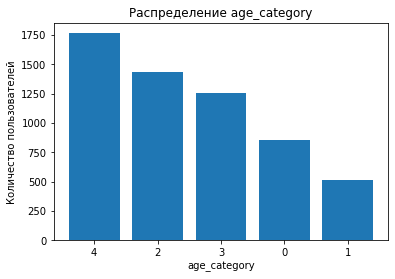

In [23]:
age_category = df['age_category'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(age_category.index.astype(str), age_category.values)
plt.xlabel('age_category')
plt.ylabel('Количество пользователей')
plt.title('Распределение age_category')
plt.show()

In [24]:
age_category

age_category
4    1766
2    1439
3    1254
0     853
1     514
Name: count, dtype: int64

в данных сильный дисбаланс классов: представителей класса 1 более чем в 3 раза меньше представителей 4 класса. 

### Анализ признаков на пригодность 

поле user_id уникально для каждой строки => не несет никакой ифнормации. удалим из датафрейма. остальные ненужные поля отсеим после анализа мультиколлинеарности. 

In [25]:
df = df.drop(columns='user_id')

In [26]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age_category                5826 non-null   int64  
 1   sessions_per_day            5826 non-null   float64
 2   site_cat_Category 01_share  5427 non-null   float64
 3   site_cat_Category 02_share  5179 non-null   float64
 4   site_cat_Category 03_share  4808 non-null   float64
 5   site_cat_Category 04_share  5600 non-null   float64
 6   site_cat_Category 05_share  5669 non-null   float64
 7   site_cat_Category 06_share  5693 non-null   float64
 8   site_cat_Category 07_share  5530 non-null   float64
 9   site_cat_Category 08_share  5463 non-null   float64
 10  site_cat_Category 09_share  5597 non-null   float64
 11  site_cat_Category 10_share  5576 non-null   float64
 12  site_cat_Category 11_share  5167 non-null   float64
 13  site_cat_Category 12_share  5342 

### Стратегия обработки пропущенных значений 

In [27]:
df.isna().sum().sort_values(ascending=False)/len(df)

site_cat_Category 13_share    0.230003
site_cat_Category 03_share    0.174734
site_cat_Category 11_share    0.113114
site_cat_Category 02_share    0.111054
site_cat_Category 14_share    0.106419
site_cat_Category 12_share    0.083076
site_cat_Category 16_share    0.075352
site_cat_Category 18_share    0.069344
site_cat_Category 01_share    0.068486
site_cat_Category 08_share    0.062307
site_cat_Category 15_share    0.060934
site_cat_Category 17_share    0.059046
site_cat_Category 07_share    0.050807
site_cat_Category 10_share    0.042911
ads_activity                  0.039993
site_cat_Category 09_share    0.039307
site_cat_Category 19_share    0.038963
site_cat_Category 04_share    0.038792
primary_device                0.026948
site_cat_Category 05_share    0.026948
cloud_usage                   0.025060
site_cat_Category 06_share    0.022829
surf_depth                    0.019053
daytime_ночь_share            0.000343
daytime_вечер_share           0.000000
daytime_утро_share       

- пропуски в категориях сайта вызваны тем, что пользователь просто не посещал эту категорию. такие пропуски следует заполнить нулем  
- пропуски в поле ads_activity заполним отдельной категорией unknown, тк они могут означать как 'очень редкo', так и 'очень часто'  
- аналогчино поступим с полями primary_device и surf_depth, тк природа происхождения пропусков в этих полях тоже неизвестна, а медиана может исказить результаты  
- в поле cloud_usage пропуски заполним нулями, тк пропуски скорее всего означают, что пользователь не пользуется облачными ресурсами 
- в поле daytime_ночь_share пропуск скорее всего означает, что ночью и юзера сессий не было. заполним нулем
- в оставшихся полях пропусков нет 

### Анализ категоральных признаков 

категоральные поля: ads_activity, primary_device, surf_depth, cloud_usage. все имеют небольшое число уникальных значений. для кодирования используем OHE (кроме cloud_usage - признак уже бинарный). 

### Анализ выбросов 

In [28]:

sns.set_theme(style='darkgrid')

def plot_outliers(df, col, bins=50):
    """
    Строит boxplot и гистограмму для численного признака.
    """

    f, (ax_box, ax_hist) = plt.subplots(
        2,
        sharex=True,
        gridspec_kw={'height_ratios': (0.15, 0.85)},
        figsize=(10, 6))

    sns.boxplot(
        x=df[col],
        orient='h',
        ax=ax_box)

    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        ax=ax_hist)

    ax_box.set(xlabel='')
    ax_hist.set_xlabel(col)
    ax_hist.set_title(f'Распределение и boxplot признака {col}')

    plt.tight_layout()
    plt.show()

In [29]:
num_columns = [
    'sessions_per_day',
    'daytime_вечер_share',
    'daytime_ночь_share',
    'daytime_утро_share',
    'site_cat_Category 01_share',
    'site_cat_Category 02_share', 'site_cat_Category 03_share',
    'site_cat_Category 04_share', 'site_cat_Category 05_share',
    'site_cat_Category 06_share', 'site_cat_Category 07_share',
    'site_cat_Category 08_share', 'site_cat_Category 09_share',
    'site_cat_Category 10_share', 'site_cat_Category 11_share',
    'site_cat_Category 12_share', 'site_cat_Category 13_share',
    'site_cat_Category 14_share', 'site_cat_Category 15_share',
    'site_cat_Category 16_share', 'site_cat_Category 17_share',
    'site_cat_Category 18_share', 'site_cat_Category 19_share'
]

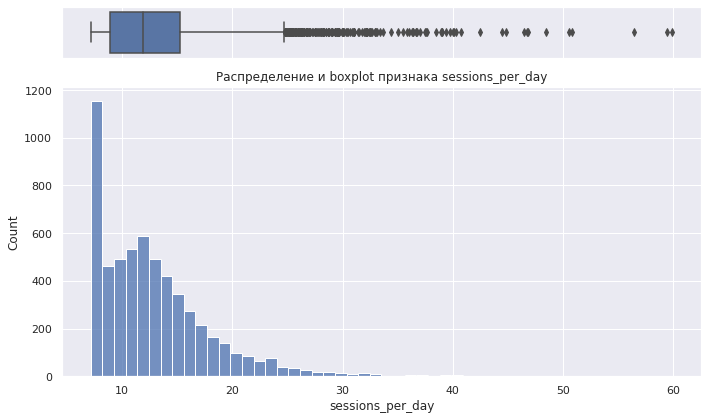

In [ ]:
plot_outliers(df, 'sessions_per_day')

много выбросов справа + разница между 5-15 сессиями в сутки сильнее влияет на таргет, чем разница 30-40. логарифмируем переменную, чтобы избавиться сразу от двух недостатков. 

In [31]:
df['sessions_per_day'] = np.log1p(df['sessions_per_day'])

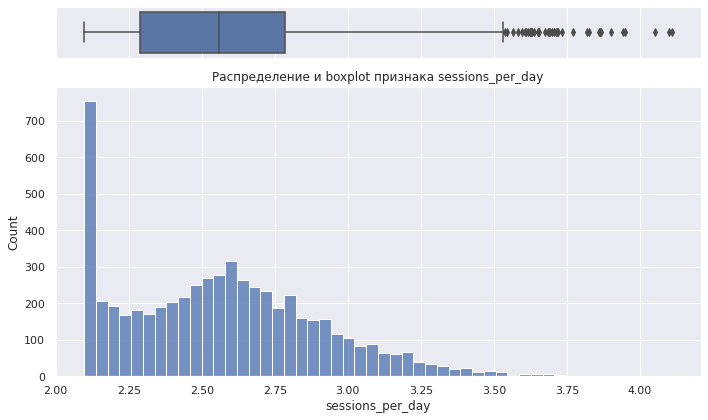

In [ ]:
plot_outliers(df, 'sessions_per_day')

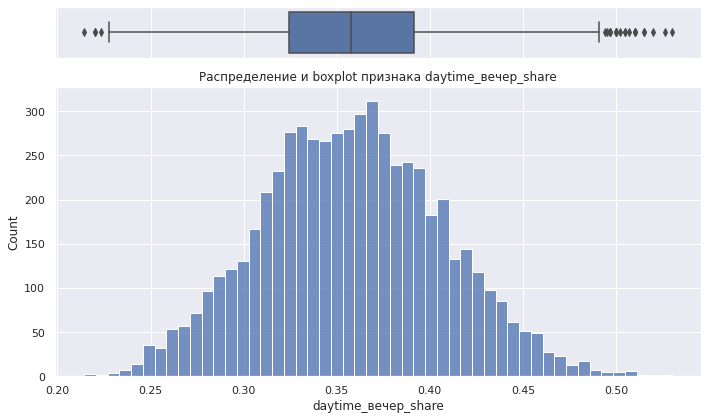

In [ ]:
plot_outliers(df, 'daytime_вечер_share')

распределение похоже на нормальное. выбросы реалистичны. оставим как есть 

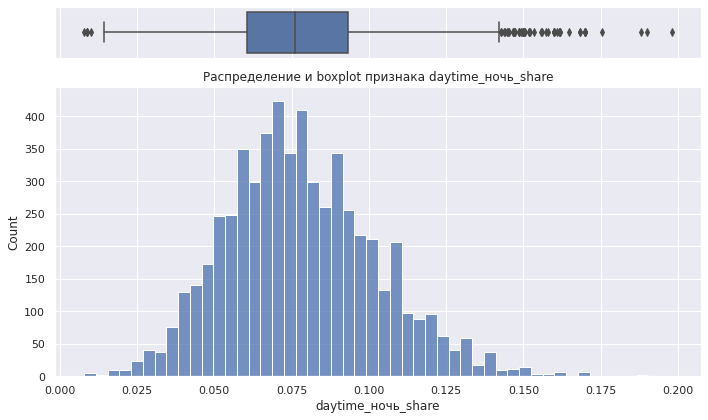

In [ ]:
plot_outliers(df, 'daytime_ночь_share')

аналогично 

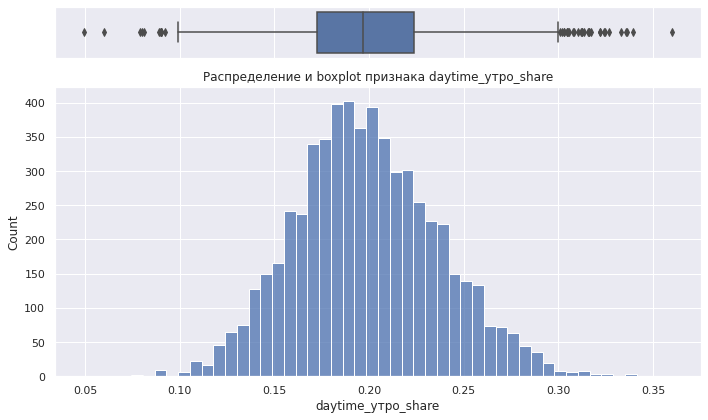

In [ ]:
plot_outliers(df, 'daytime_утро_share')

аналогично 

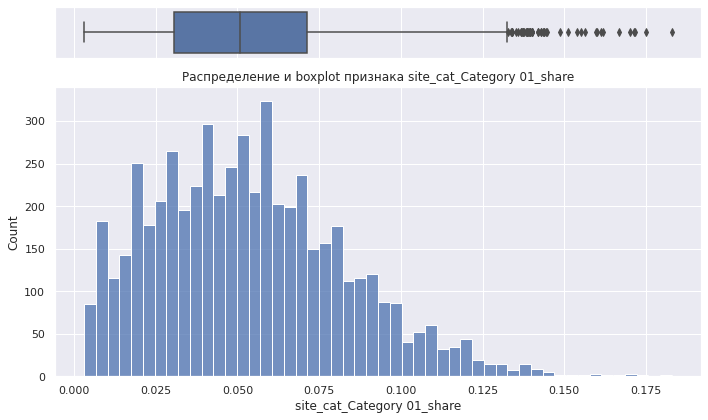

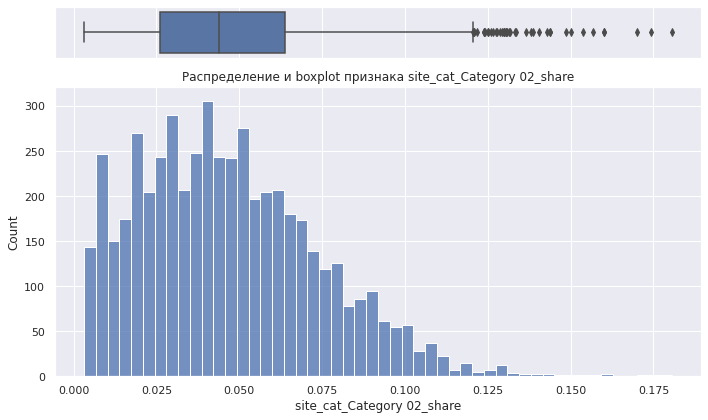

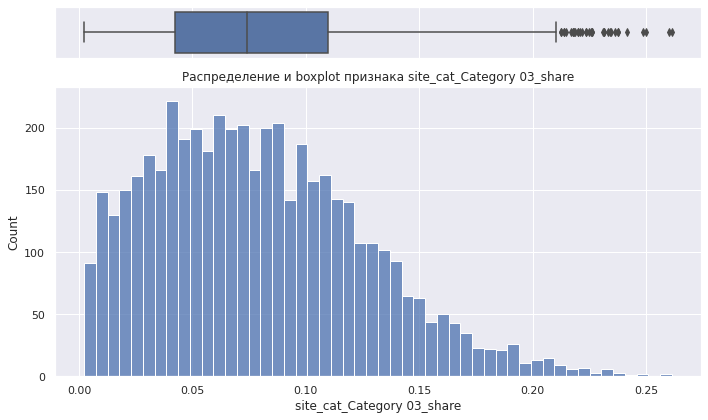

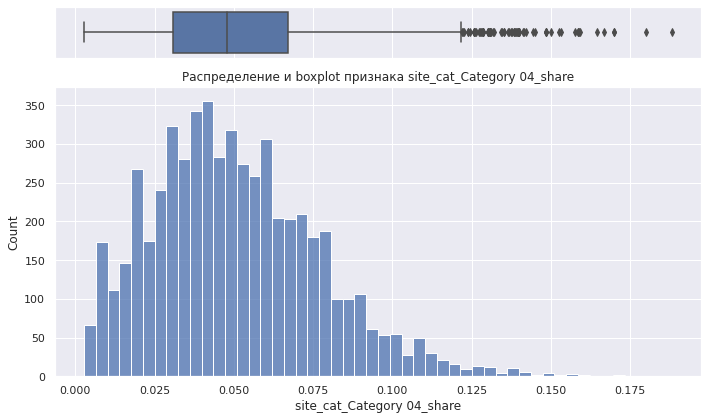

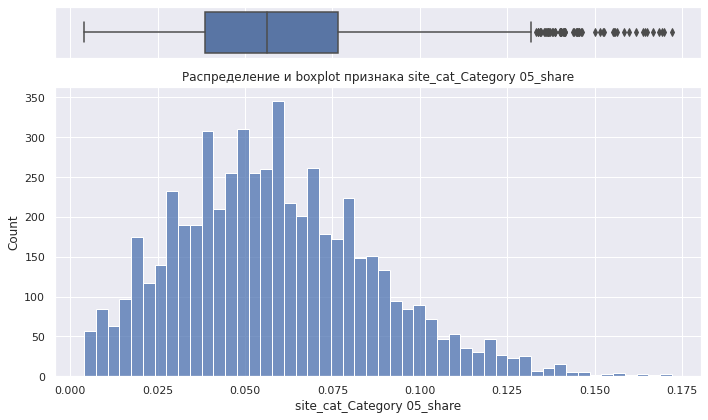

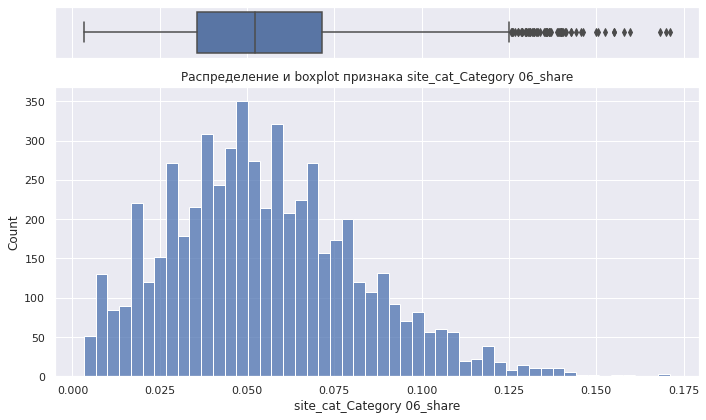

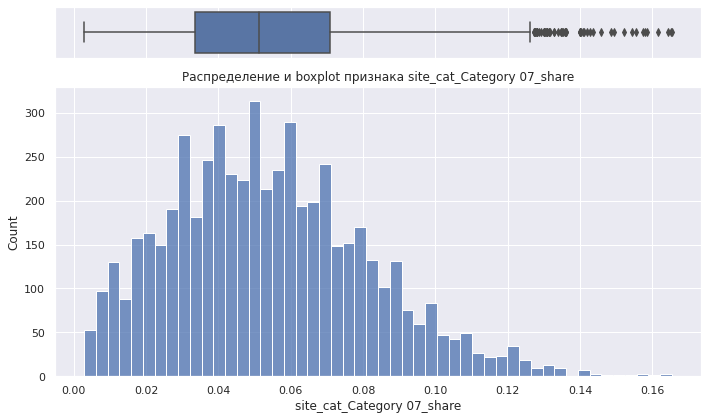

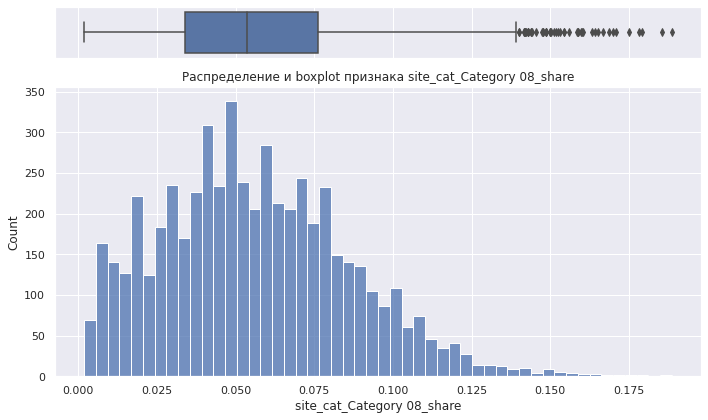

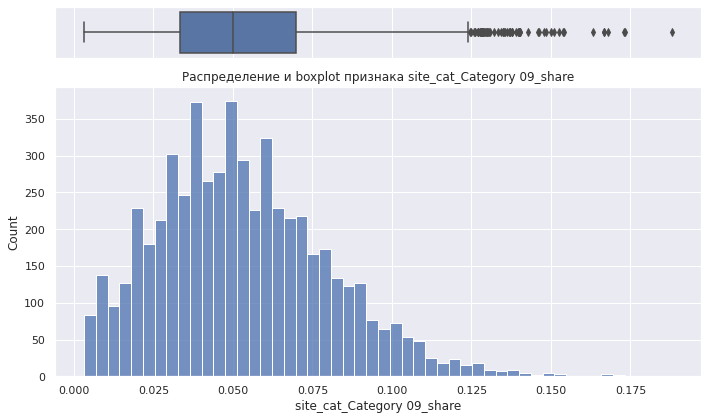

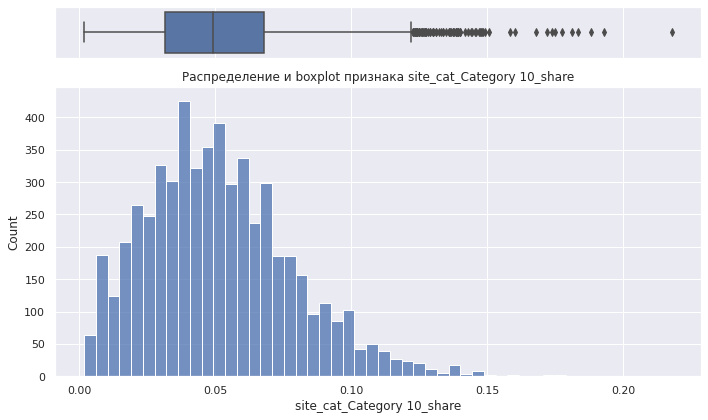

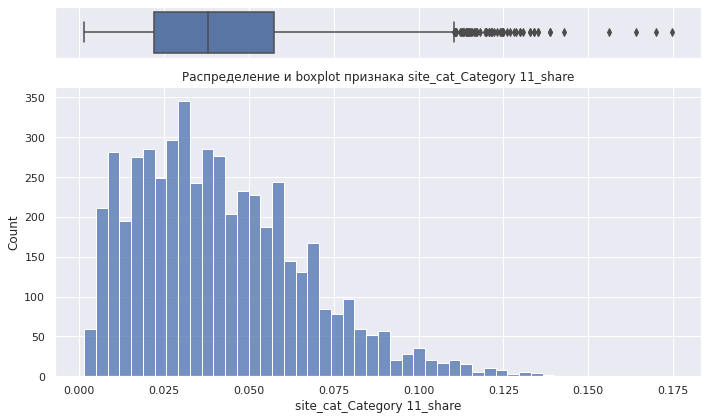

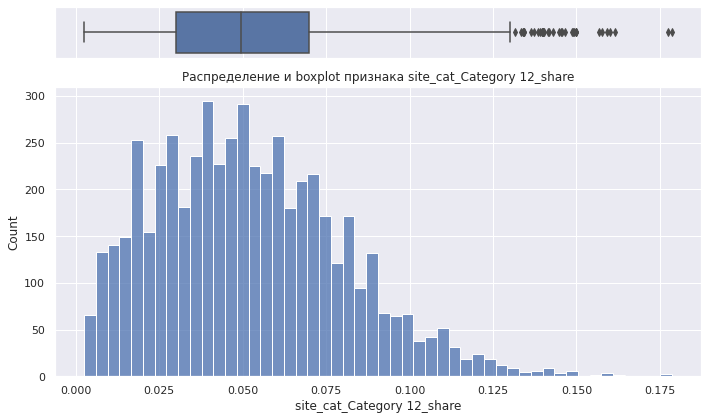

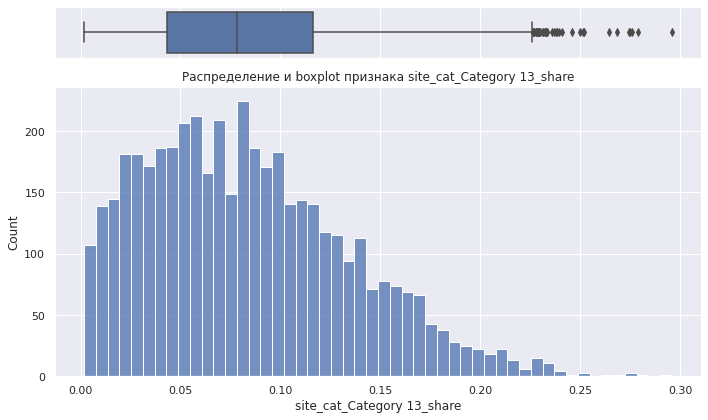

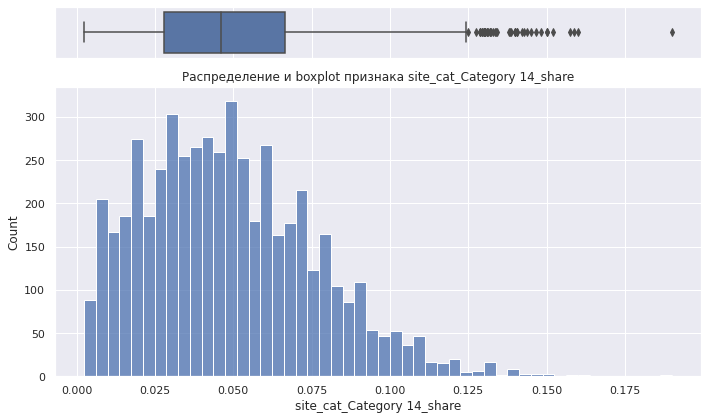

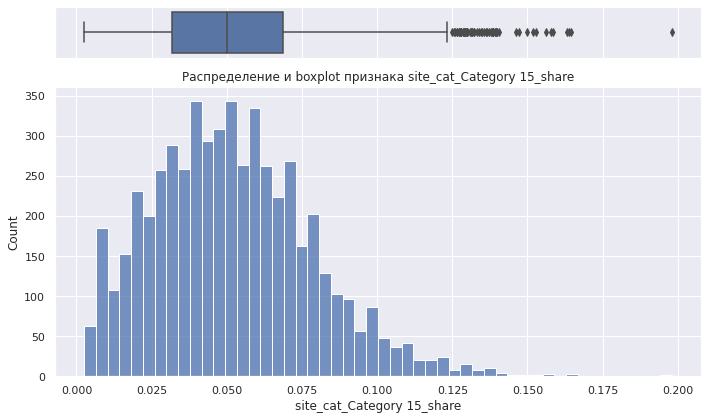

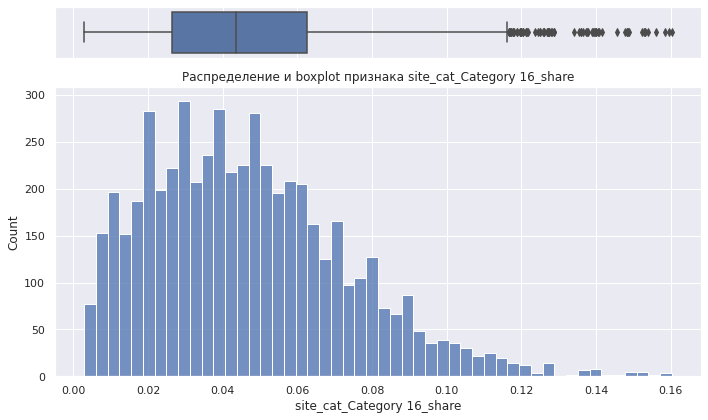

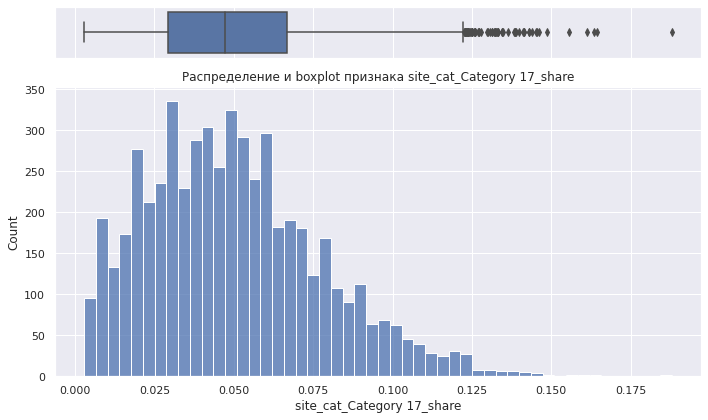

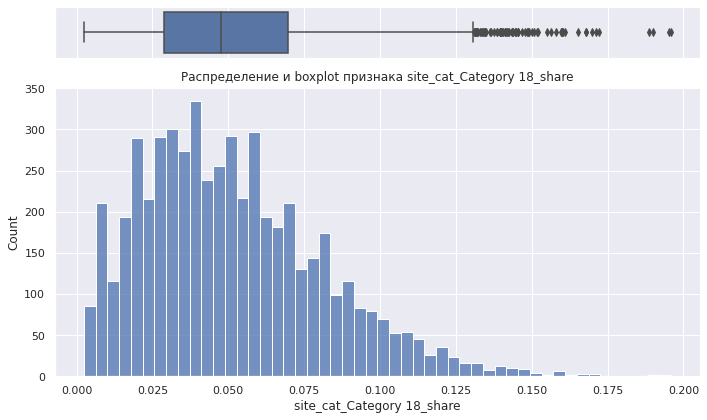

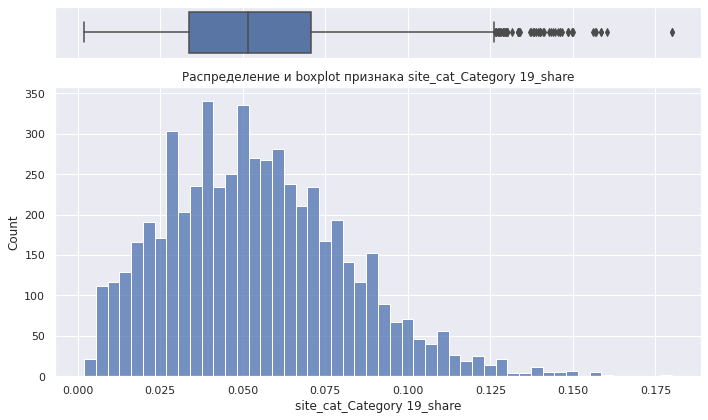

In [36]:
cols = [
    'site_cat_Category 01_share',
    'site_cat_Category 02_share', 'site_cat_Category 03_share',
    'site_cat_Category 04_share', 'site_cat_Category 05_share',
    'site_cat_Category 06_share', 'site_cat_Category 07_share',
    'site_cat_Category 08_share', 'site_cat_Category 09_share',
    'site_cat_Category 10_share', 'site_cat_Category 11_share',
    'site_cat_Category 12_share', 'site_cat_Category 13_share',
    'site_cat_Category 14_share', 'site_cat_Category 15_share',
    'site_cat_Category 16_share', 'site_cat_Category 17_share',
    'site_cat_Category 18_share', 'site_cat_Category 19_share'
]

for col in cols:
    plot_outliers(df, col)

у всех полей распределениепохоже на нормальное, но с правым хвостом. выбросы тут тоже реалистичны. ничего не будем с ними делать. 

**Итого**  
  
- логарифмировали поле sessions_per_day
- все остльные поля решили оставить как есть: у них распределения похожи на нормальное, выбросы реалистичны

### Мультиколлинеарность 

для поиска мультиколлинеарности построим матрицу корреляций phik, а потом дополнительно посчитаем кф-ты VIF (построим регрессию каждого признака на остальные фичи и посчитаем объясняющую способность). чем лучше фича линейно объясняется другими, тем выше мультиколлинеарность. 
также временно заполним все проупски для нахождения корреляции (иначе phik не будто работать). используем уже разработанную стратегию заполнения. тк значения, которыми будут заполнены пропуски, это константы, а не статистики, то можем использовать весь df без разделения на выборки - утечки не будет. факт наличия теста не должен сказываться на связи между переменными. 

In [37]:
df_copy = df.copy()

fill_0_columns = ['site_cat_Category 01_share',
       'site_cat_Category 02_share', 'site_cat_Category 03_share',
       'site_cat_Category 04_share', 'site_cat_Category 05_share',
       'site_cat_Category 06_share', 'site_cat_Category 07_share',
       'site_cat_Category 08_share', 'site_cat_Category 09_share',
       'site_cat_Category 10_share', 'site_cat_Category 11_share',
       'site_cat_Category 12_share', 'site_cat_Category 13_share',
       'site_cat_Category 14_share', 'site_cat_Category 15_share',
       'site_cat_Category 16_share', 'site_cat_Category 17_share',
       'site_cat_Category 18_share', 'site_cat_Category 19_share',
       'cloud_usage', 'daytime_ночь_share'
]


fill_unk_cols = [
    'ads_activity',
    'surf_depth',
    'primary_device'
]


df_copy[fill_0_columns] = df_copy[fill_0_columns].fillna(0)
df_copy[fill_unk_cols] = df_copy[fill_unk_cols].fillna('unknown')

In [38]:
df_copy.isna().sum().sort_values(ascending=False)/len(df_copy)

age_category                  0.0
sessions_per_day              0.0
primary_device                0.0
surf_depth                    0.0
ads_activity                  0.0
daytime_утро_share            0.0
daytime_ночь_share            0.0
daytime_вечер_share           0.0
site_cat_Category 19_share    0.0
site_cat_Category 18_share    0.0
site_cat_Category 17_share    0.0
site_cat_Category 16_share    0.0
site_cat_Category 15_share    0.0
site_cat_Category 14_share    0.0
site_cat_Category 13_share    0.0
site_cat_Category 12_share    0.0
site_cat_Category 11_share    0.0
site_cat_Category 10_share    0.0
site_cat_Category 09_share    0.0
site_cat_Category 08_share    0.0
site_cat_Category 07_share    0.0
site_cat_Category 06_share    0.0
site_cat_Category 05_share    0.0
site_cat_Category 04_share    0.0
site_cat_Category 03_share    0.0
site_cat_Category 02_share    0.0
site_cat_Category 01_share    0.0
cloud_usage                   0.0
dtype: float64

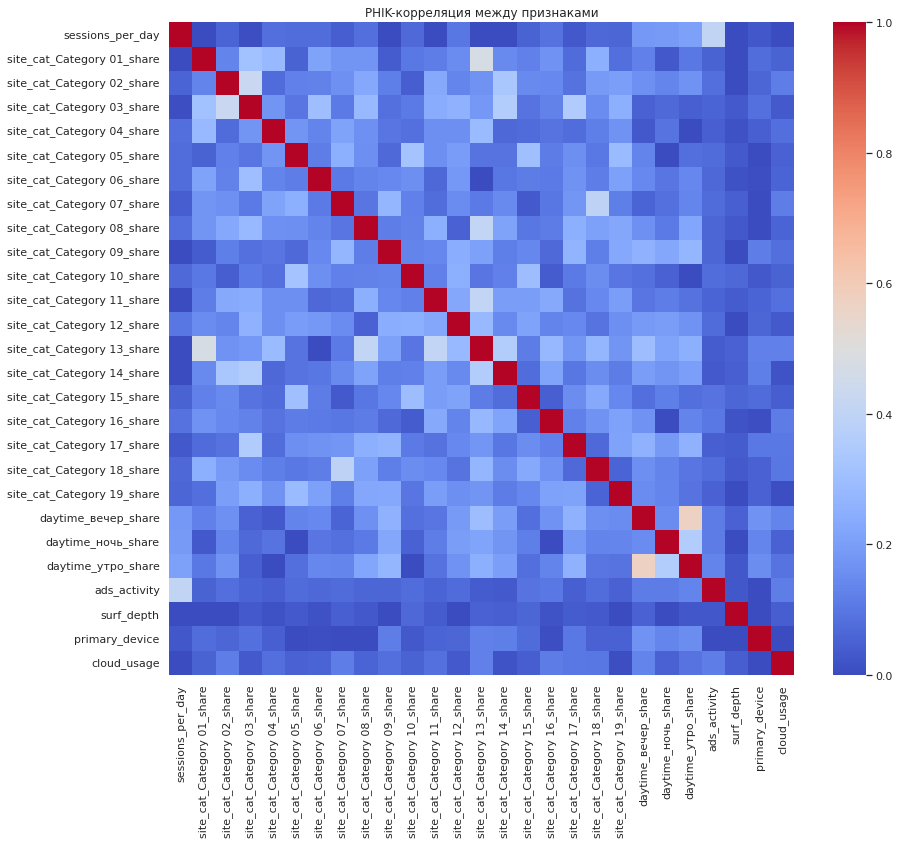

In [39]:
X = df_copy.drop(columns=['age_category'])


# считаем phik
phik_matrix = X.phik_matrix(interval_cols=num_columns)

# строим heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_matrix,
    cmap='coolwarm',
    vmin=0,
    vmax=1)

plt.title('PHIK-корреляция между признаками')
plt.show()

все корреляции приемлемы

In [40]:
X = df_copy[num_columns].copy()
X['const'] = 1.0


vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df["VIF"] = [round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
23,const,1764.42
16,site_cat_Category 13_share,8.68
6,site_cat_Category 03_share,5.67
4,site_cat_Category 01_share,3.40
15,site_cat_Category 12_share,3.13
11,site_cat_Category 08_share,3.12
22,site_cat_Category 19_share,2.85
17,site_cat_Category 14_share,2.80
18,site_cat_Category 15_share,2.58
10,site_cat_Category 07_share,2.55


8.62 - очень высокий кф (R2 регрессии site_cat_Category 13_share на осталные переменные высокий). удалим поле site_cat_Category 13_share

In [41]:
df = df.drop(columns=['site_cat_Category 13_share'])
df_copy = df_copy.drop(columns=['site_cat_Category 13_share'])

In [42]:
X = X.drop(columns=['site_cat_Category 13_share'])

vif_df = pd.DataFrame()
vif_df['feature'] = X.columns
vif_df["VIF"] = [round(variance_inflation_factor(X.values, i), 2) for i in range(X.shape[1])]

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
22,const,624.24
6,site_cat_Category 03_share,3.18
19,site_cat_Category 17_share,1.91
10,site_cat_Category 07_share,1.87
5,site_cat_Category 02_share,1.70
8,site_cat_Category 05_share,1.70
3,daytime_утро_share,1.67
13,site_cat_Category 10_share,1.62
7,site_cat_Category 04_share,1.61
1,daytime_вечер_share,1.60


все кф приемлемы 

### Итоги EDA 
  
- таргет имеет неравномерное распределение: количество наблюдений класса 4 более чем в 3 раза превышает количество наблюдений в классе 1     
- разработана стратегия заполнения пропусков     
- разработана стратегия для кодирования категоральных признаков   
- логарифмировали поле sessions_per_day   
- удалено поле site_cat_Category 13_share (высокий кф VIF) 

## Предобработка данных и построение пайплайнов 

### Разделение данных на трейн и тест 

In [43]:
X = df.drop(columns=['age_category'])
y = df['age_category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    stratify=y,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((4660, 26), (1166, 26))

In [44]:
# проверим сохранение пропорций классов в трейне и тесте 
 
y_test.value_counts(normalize=True), y_train.value_counts(normalize=True)

(age_category
 4    0.302744
 2    0.246998
 3    0.215266
 0    0.146655
 1    0.088336
 Name: proportion, dtype: float64,
 age_category
 4    0.303219
 2    0.246996
 3    0.215236
 0    0.146352
 1    0.088197
 Name: proportion, dtype: float64)

пропорция классов сохранена 

### Пайплайн предобработки данных 

In [45]:
cat_fill_unknown_columns = ['ads_activity', 'primary_device', 'surf_depth']
cat_fill_0_columns = 'cloud_usage'

num_columns = [
    'sessions_per_day',
    'daytime_вечер_share',
    'daytime_ночь_share',
    'daytime_утро_share',
    'site_cat_Category 01_share',
    'site_cat_Category 02_share', 'site_cat_Category 03_share',
    'site_cat_Category 04_share', 'site_cat_Category 05_share',
    'site_cat_Category 06_share', 'site_cat_Category 07_share',
    'site_cat_Category 08_share', 'site_cat_Category 09_share',
    'site_cat_Category 10_share', 'site_cat_Category 11_share',
    'site_cat_Category 12_share',
    'site_cat_Category 14_share', 'site_cat_Category 15_share',
    'site_cat_Category 16_share', 'site_cat_Category 17_share',
    'site_cat_Category 18_share', 'site_cat_Category 19_share'
]
# пересоздал, чтобы удалить site_cat_Category 13_share
# все численные переменные заполним нулями. там, где нет пропусков - ничего не произойдет

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        # категоральные unknown 
        ('cat_unknown', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
         ]),
         cat_fill_unknown_columns),
        
        # cloud_usage
        ('cat_fill_0', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value=0))
         ]),
         [cat_fill_0_columns]),

        # числовые признаки
        ('num', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
             ('scaler', StandardScaler())
         ]),
         num_columns)
    ],
    remainder='drop'
)

## Обучение и оценка базовой модели

In [47]:
X_train_pr = preprocessor.fit_transform(X_train)

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [49]:
scoring_dummy = {
    "f1_macro": "f1_macro"
}

In [50]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

dummy_cv = cross_validate(
    dummy, X_train_pr, y_train,
    cv=cv, scoring=scoring_dummy, n_jobs=-1
)

In [51]:
dummy_cv.keys()

dict_keys(['fit_time', 'score_time', 'test_f1_macro'])

In [52]:
np.round(dummy_cv['test_f1_macro'], 4), np.round(np.mean(dummy_cv['test_f1_macro']), 4)

(array([0.0929, 0.0929, 0.0932, 0.0932, 0.0932]), 0.0931)

0.0937 - средний результат базовой модели с метрикой f1_macro

## Создание и отбор признаков

### Создание новых признаков 

уже был создан 1 новый признак - логарифм sessions_per_day

### Отбор признаков 

ипользуем метод прямой обертки для определения ненужных признаков 

In [53]:
estimator = LogisticRegression(
    solver='liblinear',   
    max_iter=1000,
    class_weight='balanced'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

sfs = SequentialFeatureSelector(estimator, n_features_to_select='auto', direction='forward',
                                 cv=cv, scoring='f1_macro', tol=1e-4, n_jobs = -1)

sfs.fit(X_train_pr, y_train)

selected_features = sfs.get_support() 

In [54]:
feature_names = preprocessor.get_feature_names_out()

# невыбранные
df_dropped = pd.DataFrame({
    "feature": feature_names[~selected_features],
    "selected": False
})

display(df_dropped)

,feature,selected
0,cat_unknown__ads_activity_unknown,False
1,cat_unknown__ads_activity_очень редко,False
2,cat_unknown__ads_activity_редко,False
3,cat_unknown__ads_activity_умеренно,False
4,cat_unknown__primary_device_планшет,False
5,cat_unknown__primary_device_смартфон,False
6,cat_unknown__surf_depth_unknown,False
7,cat_unknown__surf_depth_глубоко,False
8,cat_unknown__surf_depth_поверхностно,False
9,cat_unknown__surf_depth_средне,False


num__sessions_per_day не был отобран SequentialFeatureSelector по метрике F1-macro (не давал прироста качества), поэтому исключим его. категоральные оставим как есть

In [55]:
df.duplicated().sum()

0

In [56]:
df = df.drop(columns=['sessions_per_day'])
X_train = X_train.drop(columns=['sessions_per_day'])
X_test = X_test.drop(columns=['sessions_per_day'])

In [57]:
# подправим препроцессор 

num_columns = [
    'daytime_вечер_share',
    'daytime_ночь_share',
    'daytime_утро_share',
    'site_cat_Category 01_share',
    'site_cat_Category 02_share', 'site_cat_Category 03_share',
    'site_cat_Category 04_share', 'site_cat_Category 05_share',
    'site_cat_Category 06_share', 'site_cat_Category 07_share',
    'site_cat_Category 08_share', 'site_cat_Category 09_share',
    'site_cat_Category 10_share', 'site_cat_Category 11_share',
    'site_cat_Category 12_share',
    'site_cat_Category 14_share', 'site_cat_Category 15_share',
    'site_cat_Category 16_share', 'site_cat_Category 17_share',
    'site_cat_Category 18_share', 'site_cat_Category 19_share'
] 
# удалил sessions_per_day


preprocessor = ColumnTransformer(
    transformers=[
        # категоральные unknown 
        ('cat_unknown', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
             ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
         ]),
         cat_fill_unknown_columns),
        
        # cloud_usage
        ('cat_fill_0', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value=0))
         ]),
         [cat_fill_0_columns]),

        # числовые признаки
        ('num', 
         Pipeline(steps=[
             ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
             ('scaler', StandardScaler())
         ]),
         num_columns)
    ],
    remainder='drop'
)

## Подбор гиперпараметров и тестировние 

### Подбор гиперпараметров

In [58]:
param_grid_lr = {
    "clf__solver": ["liblinear"],
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__class_weight": [None, "balanced"],
    "clf__max_iter": [10000],
}

param_grid_svc = {
    "clf__kernel": ["linear", "rbf", "poly"],
    "clf__C": [0.1, 1, 10, 100],
    "clf__class_weight": ["balanced"],
    "clf__gamma": ["scale"],      
    "clf__degree": [2],          
}

In [59]:
pipe_lr = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", LogisticRegression(
        solver="liblinear",
        max_iter=10000,
        class_weight="balanced"
    ))
])

pipe_svc = Pipeline(steps=[
    ("prep", preprocessor),
    ("clf", SVC(
        kernel="linear",
        probability=False,          
        class_weight="balanced"
    ))
])

In [60]:
grid_search_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [61]:
grid_search_svc = GridSearchCV(
    estimator=pipe_svc,
    param_grid=param_grid_svc,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

In [62]:
grid_search_lr.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [63]:
grid_search_svc.fit(X_train, y_train);

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [64]:
def top_n_from_gridsearch(gs, n=10):
    """
    Возвращает DataFrame с top-n конфигурациями GridSearchCV
    """
    results = pd.DataFrame(gs.cv_results_)

    cols = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "params"
    ]

    top_n = (
        results[cols]
        .sort_values("rank_test_score")
        .head(n)
        .reset_index(drop=True)
    )

    return top_n

In [65]:
top10_lr = top_n_from_gridsearch(grid_search_lr, n=10)

top10_lr = top10_lr.rename(columns={
    "mean_test_score": "f1_macro (mean)",
    "std_test_score": "f1_macro (std)",
    "rank_test_score": "rank"
})

In [66]:
top10_svc = top_n_from_gridsearch(grid_search_svc, n=10)

top10_svc = top10_svc.rename(columns={
    "mean_test_score": "f1_macro (mean)",
    "std_test_score": "f1_macro (std)",
    "rank_test_score": "rank"
})

In [67]:
for df_grid in [top10_lr, top10_svc]:
    df_grid["f1_macro (mean)"] = df_grid["f1_macro (mean)"].round(4)
    df_grid["f1_macro (std)"] = df_grid["f1_macro (std)"].round(4)

pd.set_option('display.max_colwidth', None)

display(top10_svc)
display(top10_lr)

,rank,f1_macro (mean),f1_macro (std),params
0,1,0.8944,0.0208,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}"
1,2,0.8866,0.0206,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}"
2,3,0.8838,0.0146,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}"
3,4,0.8832,0.0210,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}"
4,5,0.8663,0.0123,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}"
5,6,0.8649,0.0166,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}"
6,7,0.8580,0.0237,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}"
7,8,0.8476,0.0226,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'poly'}"
8,9,0.8175,0.0179,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}"
9,10,0.8163,0.0213,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__degree': 2, 'clf__gamma': 'scale', 'clf__kernel': 'linear'}"


,rank,f1_macro (mean),f1_macro (std),params
0,1,0.7969,0.0161,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}"
1,2,0.7960,0.0195,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
2,3,0.7957,0.0168,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}"
3,4,0.7951,0.0190,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
4,5,0.7949,0.0182,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
5,5,0.7949,0.0182,"{'clf__C': 100, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}"
6,7,0.7949,0.0170,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
7,8,0.7948,0.0184,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}"
8,9,0.7934,0.0170,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__max_iter': 10000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}"
9,10,0.7918,0.0199,"{'clf__C': 10, 'clf__class_weight': None, 'clf__max_iter': 10000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}"


лучшей моделью оказалась SVC с ядром rbf. f1_macro на кросс-валидации - 0.8947 (0.0208). стандартное отклонение низкое - нет переобучения.

In [68]:
# финальная модель

best_pipe = grid_search_svc.best_estimator_

### Оценка на тесте 

In [69]:
y_pred_test = best_pipe.predict(X_test)

In [70]:
metrics_test = {
    "f1_macro": f1_score(y_test, y_pred_test, average="macro"),
    "precision_macro": precision_score(y_test, y_pred_test, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_test, average="macro", zero_division=0),
}

In [71]:
results_df = pd.DataFrame(
    metrics_test,
    index=["SVC best model"]
).round(4)

results_df

,f1_macro,precision_macro,recall_macro
SVC best model,0.886,0.8796,0.8946


качество на тесте осталось таким же высоким. модель готова к внедрению. 

## Подготовка артефактов модели для внедрения

In [72]:
%%writefile feature_builder.py

def build_final_df_and_X(data_dir="/datasets"):
    import pandas as pd

    FINAL_FEATURES = [
        'site_cat_Category 01_share', 'site_cat_Category 02_share',
        'site_cat_Category 03_share', 'site_cat_Category 04_share',
        'site_cat_Category 05_share', 'site_cat_Category 06_share',
        'site_cat_Category 07_share', 'site_cat_Category 08_share',
        'site_cat_Category 09_share', 'site_cat_Category 10_share',
        'site_cat_Category 11_share', 'site_cat_Category 12_share',
        'site_cat_Category 14_share', 'site_cat_Category 15_share',
        'site_cat_Category 16_share', 'site_cat_Category 17_share',
        'site_cat_Category 18_share', 'site_cat_Category 19_share',
        'daytime_вечер_share', 'daytime_ночь_share', 'daytime_утро_share',
        'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage'
    ]

    # ---- загрузка данных ----
    try:
        users = pd.read_csv(f"{data_dir}/ds_s13_users.csv")
        visits = pd.read_csv(f"{data_dir}/ds_s13_visits.csv")
        ads_activity = pd.read_csv(f"{data_dir}/ads_activity.csv")
        surf_depth = pd.read_csv(f"{data_dir}/surf_depth.csv")
        primary_device = pd.read_csv(f"{data_dir}/primary_device.csv")
        cloud_usage = pd.read_csv(f"{data_dir}/cloud_usage.csv")
    except FileNotFoundError:
        users = pd.read_csv("ds_s13_users.csv")
        visits = pd.read_csv("ds_s13_visits.csv")
        ads_activity = pd.read_csv("ads_activity.csv")
        surf_depth = pd.read_csv("surf_depth.csv")
        primary_device = pd.read_csv("primary_device.csv")
        cloud_usage = pd.read_csv("cloud_usage.csv")

    # удаление дубликатов 

    users = users.drop_duplicates(subset=['user_id'])
    visits = visits.drop_duplicates(subset=['session_id'])
    ads_activity = ads_activity.drop_duplicates(subset=['user_id'])
    surf_depth = surf_depth.drop_duplicates(subset=['user_id'])
    primary_device = primary_device.drop_duplicates(subset=['user_id'])
    cloud_usage = cloud_usage.drop_duplicates(subset=['user_id'])
    
    # ---- feature engineering ----
    visits["date"] = pd.to_datetime(visits["date"], errors="coerce")

    sessions_agg = (
        visits.groupby("user_id")
        .agg(
            total_sessions=("session_id", "nunique"),
            active_days=("date", "nunique"),
        )
        .reset_index()
    )

    sessions_agg["sessions_per_day"] = (
        sessions_agg["total_sessions"] / sessions_agg["active_days"]
    )

    sessions_agg = sessions_agg.drop(columns=["total_sessions", "active_days"])

    site_category_share = visits.pivot_table(
        index="user_id",
        columns="website_category",
        values="session_id",
        aggfunc="count",
        fill_value=0
    )

    site_category_share = site_category_share.div(
        site_category_share.sum(axis=1), axis=0
    )

    site_category_share.columns = [
        f"site_cat_{c}_share" for c in site_category_share.columns
    ]
    site_category_share = site_category_share.reset_index()

    if "site_cat_Category 20_share" in site_category_share.columns:
        site_category_share = site_category_share.drop(
            columns=["site_cat_Category 20_share"]
        )

    daytime_share = visits.pivot_table(
        index="user_id",
        columns="daytime",
        values="session_id",
        aggfunc="count",
        fill_value=0
    )

    daytime_share = daytime_share.div(
        daytime_share.sum(axis=1), axis=0
    )

    daytime_share.columns = [
        f"daytime_{c}_share" for c in daytime_share.columns
    ]
    daytime_share = daytime_share.reset_index()

    if "daytime_день_share" in daytime_share.columns:
        daytime_share = daytime_share.drop(columns=["daytime_день_share"])

    df = (
        users
        .merge(sessions_agg, on="user_id", how="left")
        .merge(site_category_share, on="user_id", how="left")
        .merge(daytime_share, on="user_id", how="left")
        .merge(ads_activity, on="user_id", how="left")
        .merge(surf_depth, on="user_id", how="left")
        .merge(primary_device, on="user_id", how="left")
        .merge(cloud_usage, on="user_id", how="left")
    )

    for col in FINAL_FEATURES:
        if col not in df.columns:
            df[col] = pd.NA

    X = df[FINAL_FEATURES].copy()
    y = df["age_category"].copy()
    user_ids = df["user_id"].copy()

    return X, y, user_ids

Overwriting feature_builder.py


In [73]:
joblib.dump(best_pipe, "age_model_pipeline.joblib")

['age_model_pipeline.joblib']

In [74]:
from feature_builder import build_final_df_and_X

best_pipe_loaded = joblib.load("age_model_pipeline.joblib")

In [75]:
X, y, user_ids = build_final_df_and_X()

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    
    stratify=y,
    random_state=RANDOM_STATE
)

In [77]:
y_pred_test_loaded = best_pipe_loaded.predict(X_test)

In [78]:
print("Max abs diff:", np.max(np.abs(y_pred_test - y_pred_test_loaded)))

Max abs diff: 0


тестирование прошло успешно. 

## Выводы о результатах работы

в рамках проекта была построена модель многоклассовой классификации возраста пользователей на основе поведенческих логов. в качестве бейзлайна использовалась модель DummyClassifier, которая показала крайне низкое качество — среднее значение F1-macro ≈ 0.094, что подтверждает сложность задачи.  
  
после объединения данных из нескольких источников, создания поведенческих признаков, корректной предобработки (кодирование категориальных признаков, масштабирование численных, работа с пропусками) и подбора гиперпараметров была обучена итоговая модель SVC. на тестовой выборке она показала существенно более высокое качество:
F1-macro = 0.8919, precision-macro = 0.8965, recall-macro = 0.8883. по сравнению с бейзлайном качество модели выросло на порядок. это подтверждает, что выбранные признаки, стратегия предобработки и модель адекватно извлекают возрастные паттерны. модель пригодна для предсказания возрастной категории пользователя, что может быть очень полезным для таргетной рекламы.